In [1]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import csv
import time
import matplotlib.pyplot as plt
import itertools as it
from IPython.core.display import HTML
from fractions import Fraction
from copy import deepcopy


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [2]:
nh_min = 16
order = 1
RK = 1

dataPts = 5

scale = 0.8

test = 1

In [3]:
if (test == 1):
    AMR = False
    Uniform = True
    Two = False
else:
    if (test == 2):
        AMR = True
        Uniform = False
        Two = False
    else:
        AMR = True
        Uniform = True
        Two = True

In [4]:
savePath = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'
saveAppend = 'Gauss' + 'ConvergTest' + str(test)

In [5]:
def GraphParams(Two, Uniform, AMR):
    if (Two):
        color1 = PT.ColorDefault(2)
        color2 = PT.ColorDefault(1)
        zorder1 = 2
        zorder2 = 3
        Advect = False
        if (Uniform):
            if (AMR):
                linestyle1 = '-'
                linestyle2 = '--'
                marker1 = 's' # Change later.
                marker2 = '^' # Change later.
                testName = 'UniformVsLMR'
            else:
                sys.exit('If Two is true, then Uniform must be true!')
        else:
            sys.exit('If Two is true, then AMR must be true!')
    
    else:
        color1 = PT.ColorDefault(0)
        color2 = PT.ColorDefault(3)
        zorder1 = 3
        zorder2 = 2
        Advect = True
        if (Uniform):
            if (AMR):
                sys.exit('If Two is false and Uniform is true, then AMR must be false!')
            else:
                linestyle1 = '-'
                linestyle2 = '-'
                marker1 = 'o' # Change later.
                marker2 = 's' # Change later.
                testName = 'Uniform1Med'
        else:
            if (AMR):
                linestyle1 = '--'
                linestyle2 = '--'
                marker1 = 'p' # Change later.
                marker2 = '^' # Change later.
                testName = 'LMR1Med'
            else:
                sys.exit('If Two and Uniform are false, then AMR must be true!')
    Maxwell = True
    return color1, color2, zorder1, zorder2, linestyle1, linestyle2, marker1, marker2, Advect, Maxwell, testName

In [6]:
color1, color2, zorder1, zorder2, linestyle1, linestyle2, marker1, marker2, Advect, Maxwell, testName = GraphParams(Two, Uniform, AMR)

In [7]:
saveName = savePath + testName + saveAppend
figsize = list(scale * np.asarray([3, 3]))
title = 'RK' + str(RK)
xLabel = 'Base Grid Resolution'
yLabel = 'Order-' + str(order) + ' Error'

In [8]:
def FakeData(nh_min, dataPts, order, RK):
    nhPower = np.arange(dataPts)
    nhVec = nh_min * (2 ** nhPower)
    refLine1 = 2. / (RK * nhVec ** (0.5 * order))
    refLine2 = 1. / (RK * nhVec ** (0.5 * order))
    slope1A = np.log(refLine1[-3] / refLine1[-2]) / np.log(nhVec[-3] / nhVec[-2])
    slope1B = np.log(refLine1[-2] / refLine1[-1]) / np.log(nhVec[-2] / nhVec[-1])
    slope1 = 0.5 * (slope1A + slope1B)
    slope2A = np.log(refLine2[-3] / refLine2[-2]) / np.log(nhVec[-3] / nhVec[-2])
    slope2B = np.log(refLine2[-2] / refLine2[-1]) / np.log(nhVec[-2] / nhVec[-1])
    slope2 = 0.5 * (slope2A + slope2B)
    slope = abs(round(0.5 * (slope1 + slope1), 1))
    slopeX = 0.4 * (nhVec[-2] + nhVec[-1])
    slopeY = (refLine1[-1] * refLine1[-2]) ** 0.5
    if (order < 4):
        slopeY = 0.1 * slopeY
    else:
        slopeY = 1.9 * slopeY
    return refLine1, refLine2, nhVec, slopeX, slopeY, slope

RK: 1 order: 1
Title!
RK: 1 order: 2
RK: 1 order: 3
RK: 1 order: 4
RK: 1 order: 5
RK: 1 order: 6
RK: 2 order: 1
Title!
RK: 2 order: 2
RK: 2 order: 3
RK: 2 order: 4
RK: 2 order: 5
RK: 2 order: 6
RK: 3 order: 1
Title!
RK: 3 order: 2
RK: 3 order: 3
RK: 3 order: 4
RK: 3 order: 5
RK: 3 order: 6


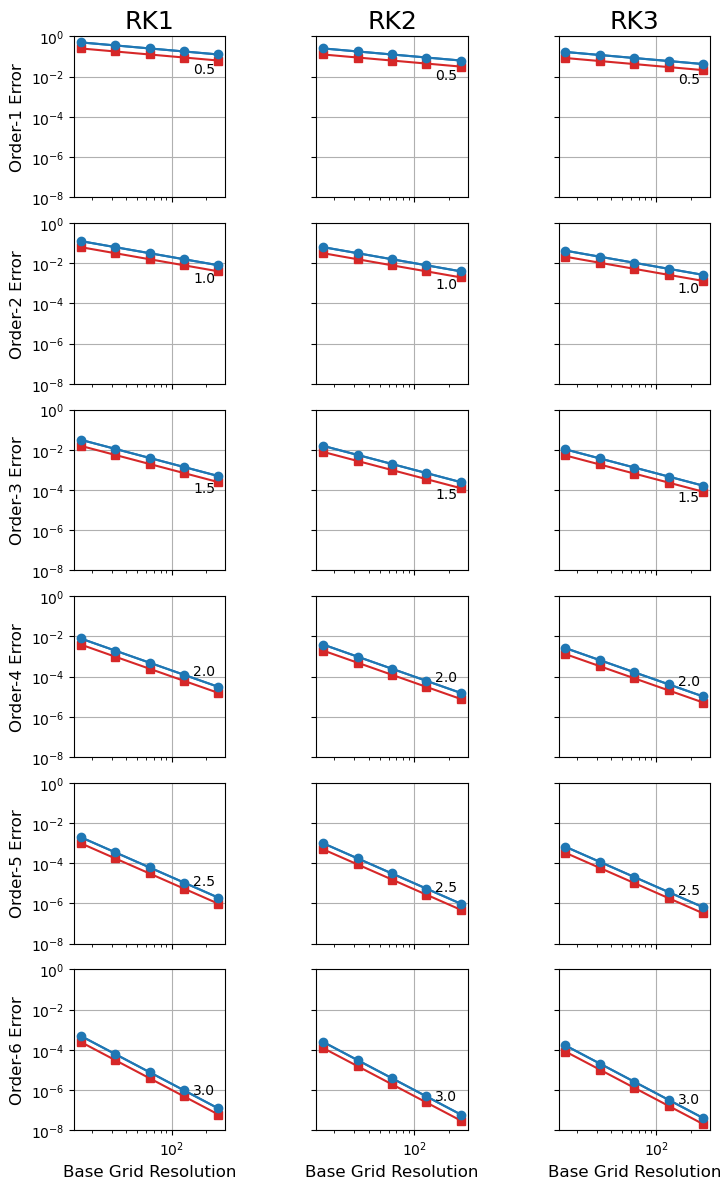

In [9]:
scootch = 0.6
x = 6 + (2 * scootch) + 0.1
y = 12
figsize = (x, y)
color1, color2, zorder1, zorder2, linestyle1, linestyle2, marker1, marker2, Advect, Maxwell, testName = GraphParams(Two, Uniform, AMR)
saveName = savePath + testName + saveAppend

# 6 columns, 3 rows → total 18 plots
fig, axs = plt.subplots(6, 3, figsize=figsize)
xLabel = 'Base Grid Resolution'

RK = 1
order = 1

for ax in axs.T.flat:
    print('RK:', RK, 'order:', order)

    title = 'RK' + str(RK)
    yLabel = 'Order-' + str(order) + ' Error'

    refLine1, refLine2, nhVec, slopeX, slopeY, slope = FakeData(nh_min, dataPts, order, RK)

    if (order == 1):
        print('Title!')
        ax.set_title(title, fontsize = 18)
    if (order == 6):
        ax.set_xlabel(xLabel, fontsize = 12)
        # ax.set_yticks(False)
        ax.tick_params(axis = 'x', labelsize = 10)
        if (RK != 1):
            ax.tick_params(axis = 'y', labelleft = False)
    else:
        ax.tick_params(axis = 'x', labelbottom = False)
    if (RK == 1):
        ax.set_ylabel(yLabel, fontsize = 12)
        # ax.set_xticks(False)
        ax.tick_params(axis = 'y', labelsize = 10)
        if (order < 6):
            ax.tick_params(axis = 'x', labelbottom = False)
    else:
        ax.tick_params(axis = 'y', labelleft = False)
    
    
    # line_kwargs = dict(linestyle=linestyle1, color=color1, zorder=zorder1)
    # marker_kwargs = dict(marker=marker1, linestyle='None', color=color1, zorder=zorder1)
    # ax.plot(nhVec, refLine1, **line_kwargs)
    # ax.plot(nhVec, refLine1, **marker_kwargs)
    ax.loglog(nhVec, refLine1)
    ax.plot(nhVec, refLine2, linestyle = linestyle2, color = color2, zorder = zorder2, marker = marker2)
    ax.plot(nhVec, refLine1, linestyle = linestyle1, color = color1, zorder = zorder1, marker = marker1)
    ax.text(slopeX, slopeY, str(slope), fontsize = 10, zorder = 4)
    ax.grid(True, zorder = 0)
    ax.set_ylim([10**-8, 1])
    if (order < 6):
        order = order + 1
    else:
        RK = RK + 1
        order = 1
    # Ticks and spines are left on — this matches axs[1, 1]

plt.tight_layout()
fig.subplots_adjust(wspace=scootch)
fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = True)
plt.show()


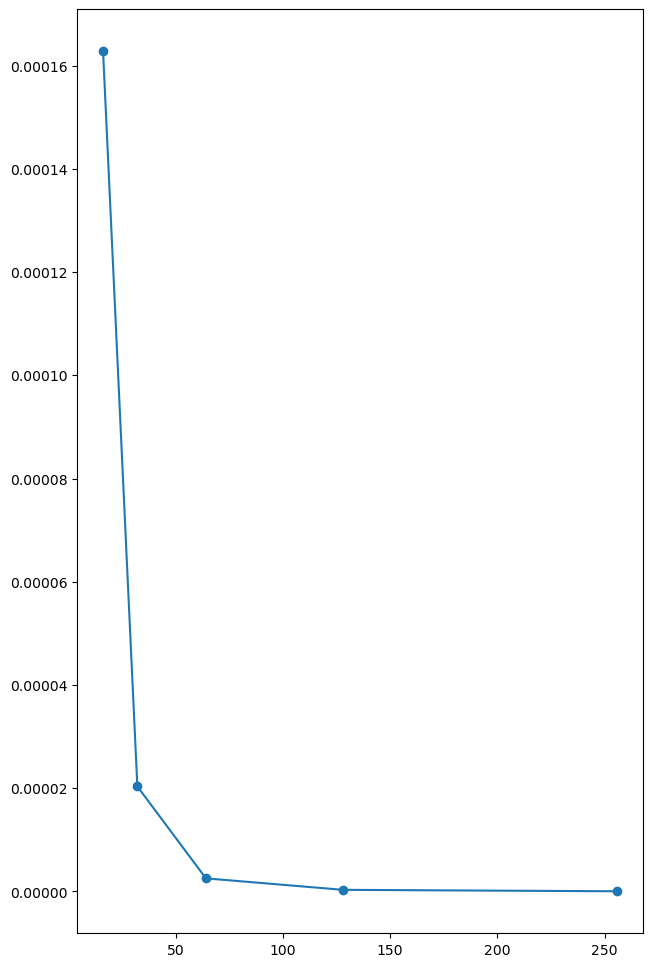

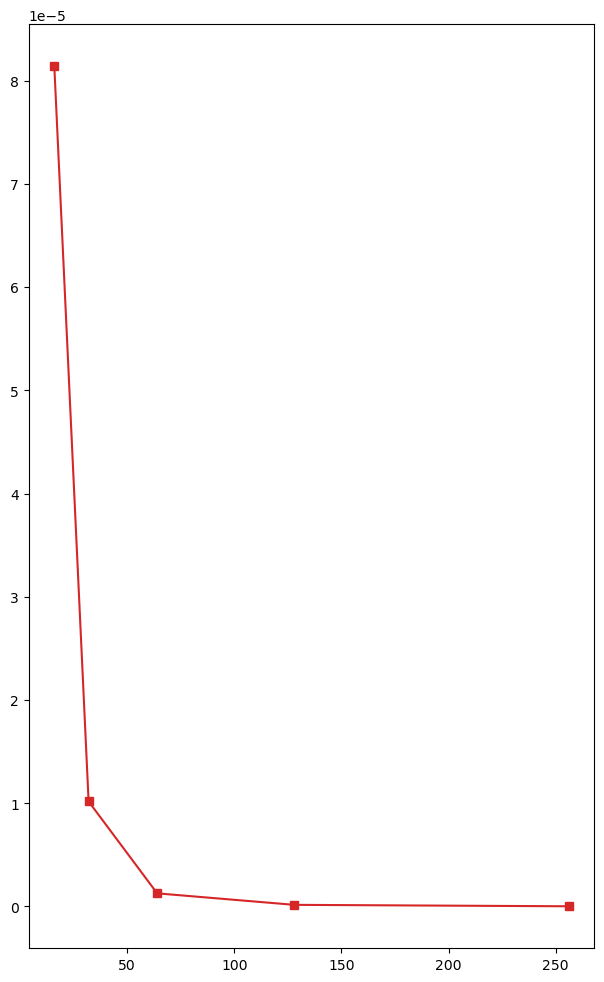

In [10]:
legends1 = []
labels1 = []
fig, ax = plt.subplots(figsize = figsize)
line1, = ax.plot(nhVec, refLine1, linestyle = linestyle1, color = color1, marker = marker1, label = '')
legends1.append(line1)
labels1.append('')
plt.show()

legends2 = []
labels2 = []
fig, ax = plt.subplots(figsize = figsize)
line2, = ax.plot(nhVec, refLine2, linestyle = linestyle2, color = color2, marker = marker2, label = '')
legends2.append(line2)
labels2.append('')
plt.show()

In [11]:
legFig1 = plt.figure()
leg1 = legFig1.legend(legends1, labels1, loc='center')
leg1.get_frame().set_alpha(0.0)
saveName = savePath + testName + 'Legend1'
legFig1.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()

<Figure size 640x480 with 0 Axes>

In [12]:
legFig2 = plt.figure()
leg2 = legFig2.legend(legends2, labels2, loc='center')
leg2.get_frame().set_alpha(0.0)
saveName = savePath + testName + 'Legend2'
legFig2.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()

<Figure size 640x480 with 0 Axes>